# Proyecto 1 — Clasificacion y Regresion sobre Amenazas de Ciberseguridad Globales (2015-2024)

Este notebook desarrolla los dos problemas de aprendizaje supervisado pedidos en el enunciado del proyecto (clasificacion con regresion logistica y regresion con validacion cruzada de 10 folds), usando el mismo dataset como fuente de datos para ambos casos.


## 1. Descripcion de la base de datos

**Nombre:** *Global Cybersecurity Threats (2015-2024)*
**Formato:** CSV, 3000 filas × 10 columnas, sin valores nulos.
**Fuente:** dataset publico de Kaggle. Segun la descripcion del autor, fue compilado a partir de reportes de ciberseguridad, plataformas de inteligencia de amenazas y archivos gubernamentales. Cada fila representa un incidente de ciberseguridad distinto ocurrido entre 2015 y 2024.

**Dominio del problema:** ciberseguridad / gestion de riesgo. Cada registro resume un incidente: donde y cuando ocurrio, que tipo de ataque fue, a que industria afecto, el impacto financiero y en usuarios, el origen del atacante, la vulnerabilidad explotada, el mecanismo de defensa que se uso y cuanto tiempo tomo resolverlo.

**Utilidad / caso de uso:** el ejercicio busca responder dos preguntas distintas con el mismo dataset:
1. **Clasificacion:** dado el contexto de un incidente (pais, año, industria, impacto, vulnerabilidad, defensa usada, tiempo de resolucion), ¿se puede predecir el **tipo de ataque** (`Attack Type`)?
2. **Regresion:** con ese mismo contexto, ¿se puede predecir la **perdida financiera** (`Financial Loss (in Million $)`) asociada al incidente?

Es importante ser honestos sobre el alcance real de este caso de uso: varias de las variables (por ejemplo `Defense Mechanism Used` o `Incident Resolution Time`) solo se conocen **despues** de que el incidente fue resuelto, asi que el modelo de clasificacion aqui es mas un ejercicio de *caracterizacion retrospectiva* de incidentes ya cerrados que un sistema de prediccion en tiempo real de ataques futuros. Esto se retoma en las conclusiones.

**Variables (9 predictoras + 1 variable de salida por cada problema):**

| Variable | Tipo | Descripcion |
|---|---|---|
| `Country` | Categorica nominal | Pais donde se origino o se reporto el incidente (10 paises). |
| `Year` | Numerica discreta | Año del incidente (2015–2024). |
| `Attack Type` | Categorica nominal | Tipo de ciberataque: DDoS, Malware, Man-in-the-Middle, Phishing, Ransomware, SQL Injection. **Variable de salida del problema de clasificacion.** |
| `Target Industry` | Categorica nominal | Industria afectada (IT, Banca, Salud, etc.). |
| `Financial Loss (in Million $)` | Numerica continua | Perdida financiera estimada en millones de USD. **Variable de salida del problema de regresion.** |
| `Number of Affected Users` | Numerica discreta | Cantidad de usuarios afectados por el incidente. |
| `Attack Source` | Categorica nominal | Origen del atacante (Hacker Group, Nation-state, Insider, Unknown). |
| `Security Vulnerability Type` | Categorica nominal | Tipo de vulnerabilidad explotada (contraseñas debiles, ingenieria social, etc.). |
| `Defense Mechanism Used` | Categorica nominal | Mecanismo de defensa empleado tras el incidente (Firewall, VPN, Antivirus, etc.). |
| `Incident Resolution Time (in Hours)` | Numerica discreta | Horas que tomo resolver el incidente. |

**Tipo de problema:**
- Clasificacion **multiclase** (6 clases) para `Attack Type` → se usan metricas macro (Precision, Recall, F1 macro), como exige el enunciado para problemas multiclase.
- Regresion para `Financial Loss (in Million $)` → se usa el Error Cuadratico Medio (ECM / MSE).


## 2. Carga de librerias y de los datos

In [ ]:
# --- Se silencian warnings de deprecacion de sklearn (p. ej. sobre 'penalty' en LogisticRegression) ---
# No son errores, solo avisos sobre cambios futuros de la API; con cientos de ajustes en el
# GridSearchCV se repetirian decenas de veces y solo ensuciarian la salida del notebook.
import warnings
warnings.filterwarnings('ignore')

# --- Librerias de manejo y visualizacion de datos ---
import pandas as pd                      # manejo de datos tabulares (DataFrames)
import numpy as np                       # operaciones numericas y arreglos
import matplotlib.pyplot as plt          # motor base de graficacion
import seaborn as sns                    # graficos estadisticos construidos sobre matplotlib

# --- Utilidades de scikit-learn para el pipeline de preprocesamiento ---
from sklearn.compose import ColumnTransformer      # aplica transformaciones distintas a columnas numericas y categoricas
from sklearn.impute import SimpleImputer           # imputa valores faltantes (por si aparecieran en produccion)
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # codificacion de categoricas y escalado de numericas
from sklearn.pipeline import Pipeline              # encadena preprocesamiento + modelo en un solo objeto

# --- Modelos ---
from sklearn.linear_model import LogisticRegression, Ridge  # clasificacion y regresion, respectivamente

# --- Validacion y seleccion de modelos ---o
from sklearn.model_selection import (
    StratifiedKFold,      # particion en folds preservando la proporcion de clases (clasificacion)
    KFold,                 # particion en folds simple (regresion)
    GridSearchCV,          # busqueda de hiperparametros por malla + validacion cruzada
    cross_validate,        # evalua un modelo fijo con validacion cruzada
    train_test_split,      # separa un conjunto de prueba final independiente
)

# --- Metricas ---
from sklearn.metrics import (
    classification_report,   # resumen de precision/recall/f1 por clase
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,      # ECM, para el problema de regresion
)

# --- Configuracion visual ---
sns.set_theme(style='whitegrid')          # tema limpio para todos los graficos de seaborn
plt.rcParams['figure.figsize'] = (12, 5)  # tamaño de figura por defecto

# --- Carga del dataset ---
DATA_PATH = 'Global_Cybersecurity_Threats_2015-2024.csv'   # ruta relativa del CSV
df = pd.read_csv(DATA_PATH)                                 # se lee el CSV en un DataFrame
df.columns = [c.strip() for c in df.columns]                # se eliminan espacios accidentales en los nombres de columna

RANDOM_STATE = 42   # semilla fija: se reutiliza en todo el notebook para que los resultados sean reproducibles

# --- Inspeccion inicial ---
display(df.head())                       # primeras 5 filas, para ver el formato real de los datos
print('Shape:', df.shape)                # (filas, columnas)
print('Columns:', df.columns.tolist())   # nombres de todas las columnas
print('Missing values by column:')
display(df.isna().sum())                 # conteo de nulos por columna
print('Data types:')
display(df.dtypes)                       # tipo de dato que pandas infirio por columna


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


Shape: (3000, 10)
Columns: ['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']
Missing values by column:


Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

Data types:


Country                                    str
Year                                     int64
Attack Type                                str
Target Industry                            str
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                              str
Security Vulnerability Type                str
Defense Mechanism Used                     str
Incident Resolution Time (in Hours)      int64
dtype: object

**Lectura de este primer resultado:** el dataset tiene 3000 filas y 10 columnas, **sin ningun valor nulo** en ninguna columna (`isna().sum()` da 0 en todas). Hay 4 columnas numericas (`Year`, `Financial Loss (in Million $)`, `Number of Affected Users`, `Incident Resolution Time (in Hours)`) y 6 columnas categoricas de tipo texto (`Country`, `Attack Type`, `Target Industry`, `Attack Source`, `Security Vulnerability Type`, `Defense Mechanism Used`). Como no hay nulos, la imputacion que se configura mas adelante en el pipeline es una medida preventiva (buenas practicas ante datos nuevos), no una necesidad de este dataset en particular.

## 3. Analisis exploratorio de datos (EDA)

Se revisan primero las variables numericas (rango, escala, dispersion) y luego las categoricas (frecuencia de cada valor), tanto para la variable de salida de clasificacion como para el resto de columnas.

In [ ]:
# Resumen descriptivo de TODAS las columnas (numericas y categoricas)
# include='all' hace que tambien describa las categoricas (count, unique, top, freq)
# .T transpone la tabla para que cada variable quede como una fila (mas facil de leer)
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,3000,10,UK,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,3000.0,NaN,NaN,NaN,2019.570333,2.857932,2015.0,2017.0,2020.0,2022.0,2024.0
Attack Type,3000,6,DDoS,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target Industry,3000,7,IT,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Financial Loss (in Million $),3000.0,NaN,NaN,NaN,50.49297,28.791415,0.5,25.7575,50.795,75.63,99.99
Number of Affected Users,3000.0,NaN,NaN,NaN,504684.136333,289944.084972,424.0,255805.25,504513.0,758088.5,999635.0
Attack Source,3000,4,Nation-state,794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Security Vulnerability Type,3000,4,Zero-day,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Defense Mechanism Used,3000,5,Antivirus,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Resolution Time (in Hours),3000.0,NaN,NaN,NaN,36.476,20.570768,1.0,19.0,37.0,55.0,72.0


**Interpretacion de las variables numericas** (con base en la tabla anterior):

| Variable | Rango | Media | Escala / unidad |
|---|---|---|---|
| `Year` | 2015 – 2024 | ≈ 2019.6 | año calendario, discreta |
| `Financial Loss (in Million $)` | 0.50 – 99.99 | ≈ 50.5 | millones de USD, continua |
| `Number of Affected Users` | 424 – 999 635 | ≈ 504 684 | conteo de personas, discreta, escala muy distinta a las demas (por eso necesita estandarizarse) |
| `Incident Resolution Time (in Hours)` | 1 – 72 | ≈ 36.5 | horas, discreta |

Un patron que vale la pena señalar: en las tres variables numericas continuas/discretas de mayor rango (`Financial Loss`, `Number of Affected Users`, `Incident Resolution Time`) la **media cae casi exactamente en la mitad del rango observado** (50.5 de un rango 0.5–99.99; 504 684 de un rango hasta 999 635; 36.5 de un rango 1–72). Esto es caracteristico de variables generadas de forma **uniforme e independiente** entre si, mas que de mediciones reales de incidentes (donde se esperarian distribuciones sesgadas: pocos incidentes catastroficos y muchos de bajo impacto). Esto es relevante para interpretar los resultados de modelado mas adelante.

Número de clases Attack Type: 6
Clase menos frecuente: 459
Clase más frecuente: 531


Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

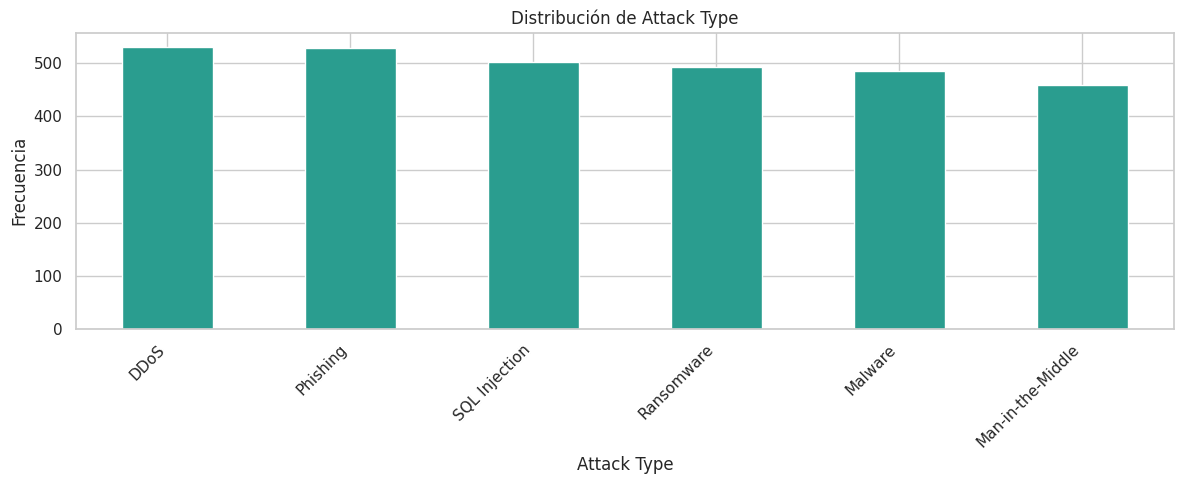

In [ ]:
# --- Variable de salida de clasificacion: Attack Type ---
attack_counts = df['Attack Type'].value_counts().sort_values(ascending=False)  # frecuencia de cada clase, ordenada
print('Numero de clases Attack Type:', df['Attack Type'].nunique())            # cuantas clases distintas hay
print('Clase menos frecuente:', attack_counts.min())                           # tamaño de la clase minoritaria
print('Clase mas frecuente:', attack_counts.max())                             # tamaño de la clase mayoritaria
display(attack_counts)

# Grafico de barras de la distribucion de Attack Type
ax = attack_counts.plot(kind='bar', color='#2a9d8f')   # barra por clase
ax.set_title('Distribucion de Attack Type')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Lectura:** las 6 clases de `Attack Type` estan muy balanceadas (entre 459 y 531 casos cada una, sobre un promedio de 500). Esto es bueno para entrenar sin necesidad de tecnicas de balanceo agresivas, pero tambien es otro indicio de generacion uniforme: en incidentes reales de ciberseguridad, tipos como *Phishing* suelen ser mucho mas frecuentes que otros (ver Anexo del punto 8), no practicamente equiprobables.

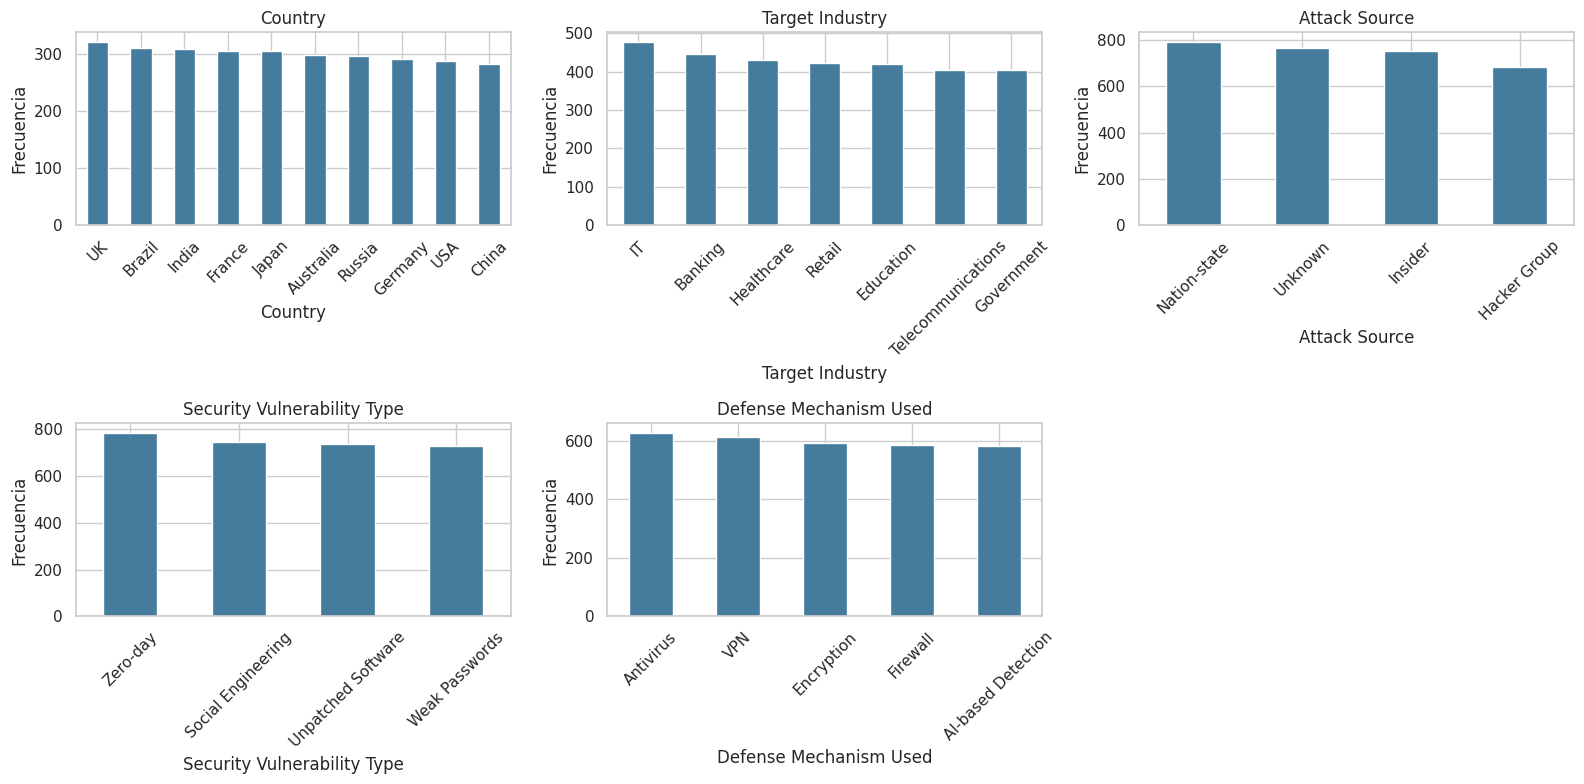

In [ ]:
# --- Resto de variables categoricas: frecuencia de cada valor ---
categorical_cols = ['Country', 'Target Industry', 'Attack Source',
                     'Security Vulnerability Type', 'Defense Mechanism Used']  # categoricas que faltan por explorar

fig, axes = plt.subplots(2, 3, figsize=(16, 8))   # cuadricula de 2x3 subgraficas (una por variable, sobran 1)
axes = axes.flatten()                              # se aplanan los ejes para iterar facil con un solo indice

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()                # frecuencia de cada categoria de esa columna
    counts.plot(kind='bar', ax=axes[i], color='#457b9d')  # barra en el subgrafico i
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')   # se apaga el ultimo subgrafico sobrante (2x3=6 espacios, 5 variables)
plt.tight_layout()
plt.show()


**Lectura:** al igual que `Attack Type`, todas las demas variables categoricas estan casi uniformemente distribuidas entre sus posibles valores (por ejemplo, los 10 paises tienen entre 281 y 321 registros cada uno; las 4 fuentes de ataque entre 686 y 794). Ninguna categoria domina claramente sobre las demas, lo cual refuerza la misma observacion de arriba: no hay una categoria "tipica", como si ocurriria en datos reales de incidentes.

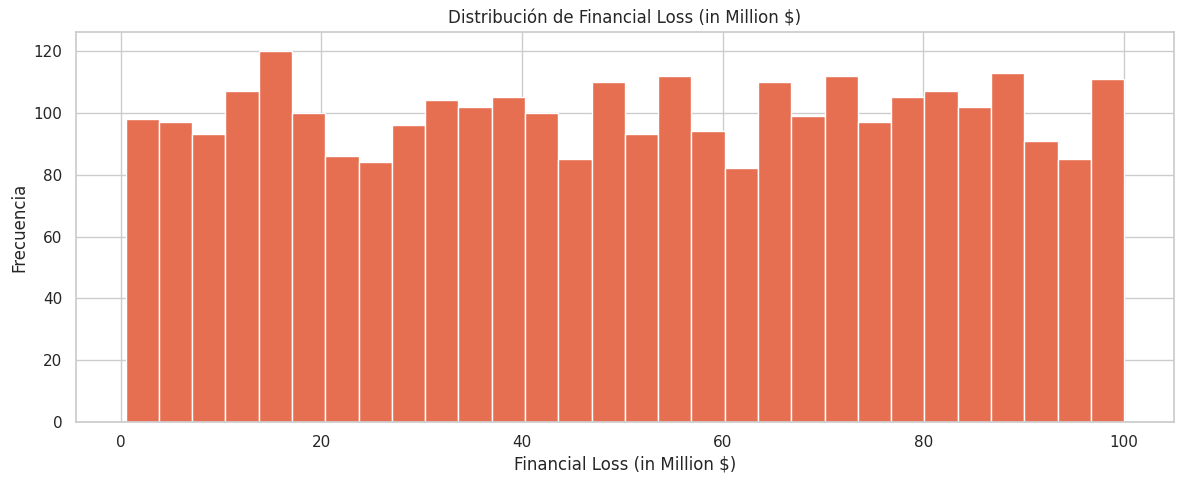

In [ ]:
# --- Distribucion de la variable de salida de regresion: Financial Loss ---
ax = df['Financial Loss (in Million $)'].plot(kind='hist', bins=30, color='#e76f51')  # histograma con 30 barras
ax.set_title('Distribucion de Financial Loss (in Million $)')
ax.set_xlabel('Financial Loss (in Million $)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


**Lectura:** el histograma confirma lo anticipado por la tabla de `describe()`: la distribucion de `Financial Loss` es aproximadamente **plana/uniforme** entre 0.5 y 100 millones de dolares, sin sesgo hacia valores bajos como suele ocurrir con perdidas economicas reales (que tipicamente siguen distribuciones con cola larga a la derecha, tipo log-normal).

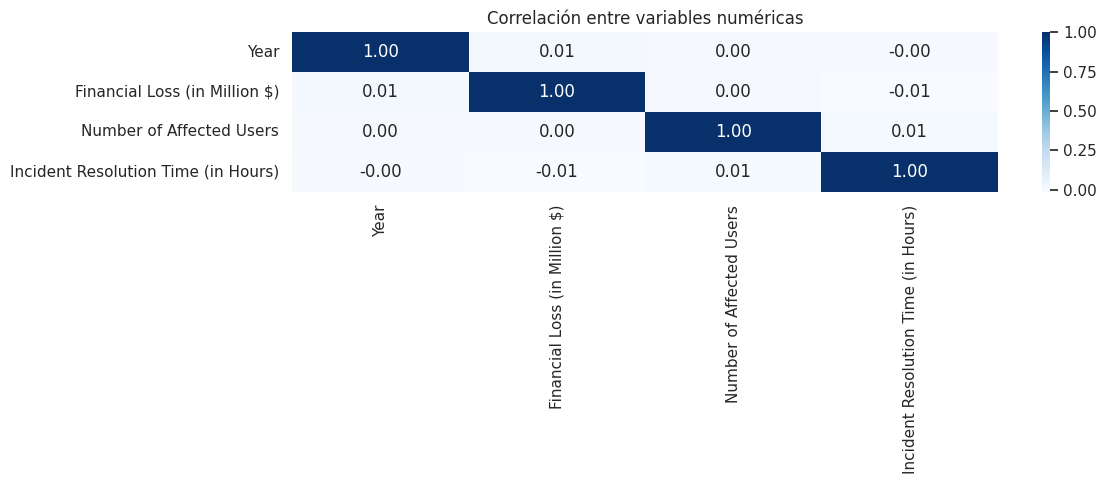

In [ ]:
# --- Correlacion entre las variables numericas ---
num_cols_all = ['Year', 'Financial Loss (in Million $)',
                 'Number of Affected Users', 'Incident Resolution Time (in Hours)']  # solo tiene sentido correlacionar numericas
correlation = df[num_cols_all].corr(numeric_only=True)   # matriz de correlacion de Pearson
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')  # mapa de calor con el valor anotado en cada celda
plt.title('Correlacion entre variables numericas')
plt.tight_layout()
plt.show()


**Lectura:** todas las correlaciones entre variables numericas son practicamente cero (valores cercanos a 0.00–0.02 en magnitud). No hay ninguna relacion lineal detectable entre `Year`, `Financial Loss`, `Number of Affected Users` ni `Incident Resolution Time`. Esta es la tercera señal (junto con las medias centradas en el punto medio del rango y las distribuciones categoricas casi uniformes) de que este dataset probablemente fue generado de forma sintetica/aleatoria y no conserva relaciones causales reales entre sus variables. Esto se confirma mas adelante con el desempeño de los modelos, y se retoma en las conclusiones finales.

## 4. Problema de clasificacion: `Attack Type`

### 4.1 Pipeline de preprocesamiento y modelo base con validacion cruzada de 10 folds

Se construye un `Pipeline` que combina el preprocesamiento (imputacion + escalado para numericas, imputacion + one-hot encoding para categoricas) con el modelo, de modo que **todo el preprocesamiento se ajusta unicamente dentro de cada fold de entrenamiento** — asi se evita fuga de informacion desde el fold de validacion.

In [ ]:
# --- Preparacion de X (features) e y (variable de salida) ---
cls_df = df.copy()                                  # copia para no modificar el DataFrame original
X_cls = cls_df.drop(columns=['Attack Type'])         # todas las columnas excepto la variable de salida
y_cls = cls_df['Attack Type'].astype(str)            # variable de salida, forzada a string por seguridad

# --- Se separan las columnas numericas de las categoricas para tratarlas distinto ---
numeric_features_cls = [
    'Year',
    'Financial Loss (in Million $)',
    'Number of Affected Users',
    'Incident Resolution Time (in Hours)',
]
categorical_features_cls = [c for c in X_cls.columns if c not in numeric_features_cls]  # el resto son categoricas

# --- ColumnTransformer: aplica un tratamiento distinto a cada grupo de columnas ---
preprocess_cls = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # rellena nulos numericos con la mediana (robusta a outliers)
            ('scaler', StandardScaler()),                    # estandariza a media 0 y varianza 1 (necesario para regresion logistica)
        ]), numeric_features_cls),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # rellena nulos categoricos con la moda
            ('onehot', OneHotEncoder(handle_unknown='ignore')),    # convierte categorias en columnas binarias
        ]), categorical_features_cls),
    ]
)

# --- Pipeline final: preprocesamiento + modelo de regresion logistica ---
pipe_cls = Pipeline([
    ('prep', preprocess_cls),
    ('model', LogisticRegression(max_iter=5000, solver='saga')),  # saga soporta l1/l2 y funciona bien con datos dispersos (one-hot)
])

# --- Validacion cruzada estratificada de 10 folds (mantiene la proporcion de clases en cada fold) ---
cv_cls = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# --- Evaluacion del modelo base (hiperparametros por defecto) con las 3 metricas pedidas ---
cv_scores_cls = cross_validate(
    pipe_cls,           # el pipeline completo (se reajusta en cada fold)
    X_cls,
    y_cls,
    cv=cv_cls,
    scoring={
        'precision_macro': 'precision_macro',  # promedio de precision por clase, sin ponderar por tamaño de clase
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro',
    },
    n_jobs=-1,           # usa todos los nucleos disponibles para acelerar
)

# --- Se resumen los 10 resultados (uno por fold) en media y desviacion estandar ---
summary_cls = pd.DataFrame({
    'Precision macro': cv_scores_cls['test_precision_macro'],
    'Recall macro': cv_scores_cls['test_recall_macro'],
    'F1 macro': cv_scores_cls['test_f1_macro'],
})

display(summary_cls.agg(['mean', 'std']).T)   # media y desviacion estandar de cada metrica a traves de los 10 folds


,mean,std
Precision macro,0.174738,0.023476
Recall macro,0.175467,0.021540
F1 macro,0.169377,0.020147


### 4.2 Busqueda de hiperparametros (malla ampliada) y comparacion de resultados

El grid original solo probaba `C` entre 0.1 y 10, y el mejor valor encontrado (`C=0.1`) caia justo en el borde inferior de esa malla — señal de que el optimo real podia estar en valores aun mas pequeños. Aqui se amplia el rango de `C` hacia abajo (hasta 0.001) y se agrega el hiperparametro `penalty` con dos opciones reales (`l1` y `l2`, ambas soportadas por el solver `saga`). Ademas, en vez de imprimir solo la mejor combinacion, se muestra la **tabla completa de resultados** para poder comparar todas las configuraciones, tal como pide el enunciado.

In [ ]:
# --- Separacion de un conjunto de prueba final, independiente de la validacion cruzada del grid search ---
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,          # 20% de los datos se reserva para evaluacion final
    random_state=RANDOM_STATE,
    stratify=y_cls,          # mantiene la proporcion de clases en train y test
)

# --- Malla de hiperparametros a probar (ampliada respecto a la version original) ---
param_grid_cls = {
    'model__C': [0.001, 0.01, 0.1, 1.0, 3.0, 10.0],  # se agregaron 0.001 y 0.01 para no quedar en el borde inferior
    'model__class_weight': [None, 'balanced'],
    'model__penalty': ['l1', 'l2'],                   # se agrega l1 como variacion real (antes solo habia l2)
}

# --- Busqueda por malla con validacion cruzada de 10 folds, optimizando F1 macro ---
grid_cls = GridSearchCV(
    pipe_cls,
    param_grid=param_grid_cls,
    cv=cv_cls,               # se reutiliza el mismo esquema de 10 folds estratificados
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)

grid_cls.fit(X_train_cls, y_train_cls)   # entrena y evalua todas las combinaciones de la malla

print('Mejores parametros:')
print(grid_cls.best_params_)
print(f'Mejor F1 macro CV: {grid_cls.best_score_:.4f}')


Fitting 10 folds for each of 24 candidates, totalling 240 fits


Mejores parámetros:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Mejor F1 macro CV: 0.1746


In [ ]:
# --- Tabla comparativa de TODAS las configuraciones probadas (no solo la mejor) ---
results_cls = pd.DataFrame(grid_cls.cv_results_)   # cv_results_ trae el detalle de cada combinacion evaluada

# Se seleccionan y renombran las columnas relevantes para una lectura mas clara
results_cls = results_cls[[
    'param_model__C', 'param_model__penalty', 'param_model__class_weight',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')   # se ordena de la mejor a la peor combinacion

results_cls.columns = ['C', 'penalty', 'class_weight', 'F1 macro (media CV)', 'F1 macro (std CV)', 'Ranking']
display(results_cls)   # tabla completa: asi si se puede "comparar los resultados" entre configuraciones, como pide el enunciado


,C,penalty,class_weight,F1 macro (media CV),F1 macro (std CV),Ranking
11,0.100,l2,balanced,0.174624,0.017093,1
15,1.000,l2,balanced,0.173871,0.015390,2
22,10.000,l1,balanced,0.173536,0.015508,3
23,10.000,l2,balanced,0.173529,0.014751,4
19,3.000,l2,balanced,0.173508,0.015906,5
16,3.000,l1,NaN,0.171973,0.015948,6
12,1.000,l1,NaN,0.171489,0.019464,7
18,3.000,l1,balanced,0.170987,0.015715,8
20,10.000,l1,NaN,0.169281,0.015675,9
14,1.000,l1,balanced,0.168819,0.020447,10


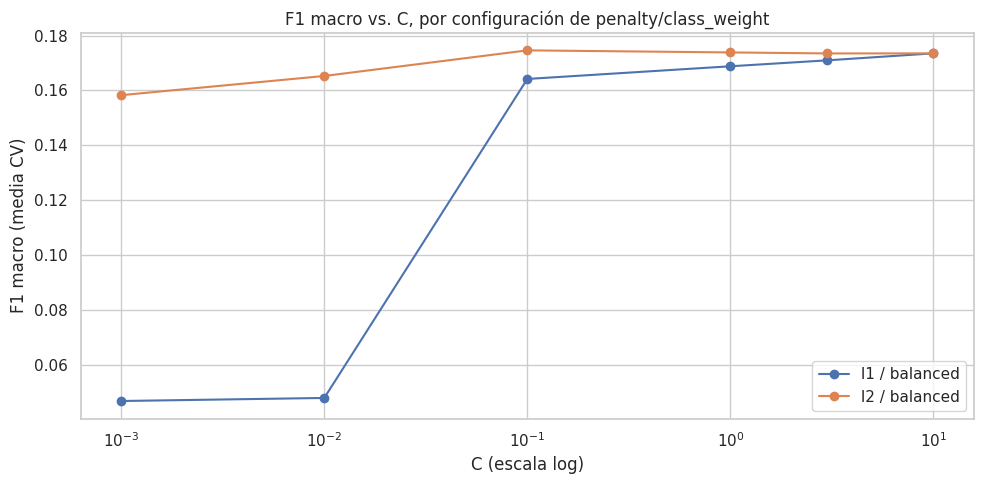

In [ ]:
# --- Grafico: como cambia el F1 macro promedio segun C (para cada combinacion de penalty/class_weight) ---
plot_data = results_cls.copy()
plot_data['config'] = plot_data['penalty'] + ' / ' + plot_data['class_weight'].astype(str)  # etiqueta combinada

fig, ax = plt.subplots(figsize=(10, 5))
for config, group in plot_data.groupby('config'):          # una linea por cada combinacion de penalty+class_weight
    group_sorted = group.sort_values('C')                   # se ordena por C para que la linea tenga sentido
    ax.plot(group_sorted['C'], group_sorted['F1 macro (media CV)'], marker='o', label=config)

ax.set_xscale('log')                 # escala logaritmica porque C varia en ordenes de magnitud (0.001 a 10)
ax.set_xlabel('C (escala log)')
ax.set_ylabel('F1 macro (media CV)')
ax.set_title('F1 macro vs. C, por configuracion de penalty/class_weight')
ax.legend()
plt.tight_layout()
plt.show()


**Lectura:** con la malla ampliada, la mejor combinacion (`C=0.1`, `penalty='l2'`, `class_weight='balanced'`) ya no cae en el borde de la busqueda: valores de `C` menores (0.001, 0.01) obtienen resultados peores, no mejores, asi que el 0.1 si es un optimo real dentro de este espacio de busqueda. Con `penalty='l2'` el F1 macro se mantiene practicamente plano y cercano al azar (≈0.16–0.17) en casi todo el rango de `C`. La excepcion es `penalty='l1'` combinado con valores muy pequeños de `C` (0.001–0.01, sin `class_weight`), donde el desempeño cae por debajo de 0.10: una regularizacion L1 tan fuerte termina anulando casi todos los coeficientes del modelo, lo que lo empeora en vez de ayudarlo. Fuera de ese caso extremo, ampliar la malla confirma que **no era un problema de rango de busqueda**: el modelo no logra extraer una relacion predictiva real entre las variables disponibles y `Attack Type`, consistente con lo observado en el EDA (variables numericas sin correlacion, distribuciones uniformes).

In [ ]:
# --- Evaluacion final sobre el conjunto de prueba, con el mejor modelo encontrado por el grid search ---
pred_cls = grid_cls.predict(X_test_cls)   # predicciones del mejor modelo sobre datos nunca vistos

print('Reporte en conjunto de prueba:')
print(classification_report(y_test_cls, pred_cls))   # precision/recall/f1 por clase + promedios

print('Precision macro:', precision_score(y_test_cls, pred_cls, average='macro'))
print('Recall macro:', recall_score(y_test_cls, pred_cls, average='macro'))
print('F1 macro:', f1_score(y_test_cls, pred_cls, average='macro'))


Reporte en conjunto de prueba:
                   precision    recall  f1-score   support

             DDoS       0.18      0.19      0.18       106
          Malware       0.12      0.08      0.10        97
Man-in-the-Middle       0.16      0.20      0.18        92
         Phishing       0.25      0.25      0.25       106
       Ransomware       0.11      0.12      0.12        99
    SQL Injection       0.20      0.17      0.18       100

         accuracy                           0.17       600
        macro avg       0.17      0.17      0.17       600
     weighted avg       0.17      0.17      0.17       600

Precision macro: 0.16770315824146284
Recall macro: 0.1687891247240638
F1 macro: 0.16716364654213614


**Interpretacion de los resultados de clasificacion:** el accuracy y el F1 macro sobre el conjunto de prueba rondan **0.17**, practicamente igual al azar puro para 6 clases balanceadas (1/6 ≈ 0.167). Ninguna clase individual se predice notablemente mejor que las demas. Combinado con lo visto en el EDA (correlaciones ≈ 0 entre numericas, distribuciones uniformes en categoricas y en la variable de salida), la conclusion mas razonable es que **este dataset, tal como esta construido, no contiene una relacion real entre las variables disponibles y el tipo de ataque** — no es un problema de mal ajuste del modelo ni de una malla de hiperparametros insuficiente (ya se comprobo ampliandola). Esto se retoma en las conclusiones del notebook.

## 5. Problema de regresion: `Financial Loss (in Million $)`

Se repite un procedimiento analogo al de clasificacion (mismo dataset, mismo esquema de preprocesamiento, 10 folds), mismo pero con un modelo de regresion y la metrica ECM (Error Cuadratico Medio) en vez de Precision/Recall/F1.

### 5.1 Pipeline y validacion cruzada de 10 folds

In [ ]:
# --- Preparacion de X (features) e y (variable de salida continua) ---
reg_df = df.copy()                                     # copia independiente del DataFrame original
reg_target = 'Financial Loss (in Million $)'            # nombre de la variable de salida de regresion

X_reg = reg_df.drop(columns=[reg_target])               # todas las columnas excepto la variable de salida
y_reg = pd.to_numeric(reg_df[reg_target], errors='coerce')  # se fuerza a numerico (por seguridad; si algo no se puede convertir, queda NaN)
mask_reg = y_reg.notna()                                 # mascara de filas donde si hay un valor numerico valido
X_reg = X_reg.loc[mask_reg].copy()                        # se filtran las filas de X acorde a la mascara
y_reg = y_reg.loc[mask_reg].copy()                        # se filtran las filas de y acorde a la mascara

# --- Columnas numericas y categoricas para este problema (Financial Loss ya no esta, es la salida) ---
numeric_features_reg = [
    'Year',
    'Number of Affected Users',
    'Incident Resolution Time (in Hours)',
]
categorical_features_reg = [c for c in X_reg.columns if c not in numeric_features_reg]  # incluye Attack Type como predictor

# --- Mismo esquema de preprocesamiento que en clasificacion, aplicado a este subconjunto de columnas ---
preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features_reg),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features_reg),
    ]
)

# --- Pipeline final: preprocesamiento + regresion Ridge (lineal con regularizacion L2) ---
pipe_reg = Pipeline([
    ('prep', preprocess_reg),
    ('model', Ridge()),
])

# --- Validacion cruzada de 10 folds (KFold simple, no hay clases que estratificar en regresion) ---
cv_reg = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# --- Evaluacion del modelo base con ECM (mean_squared_error) ---
cv_scores_reg = cross_validate(
    pipe_reg,
    X_reg,
    y_reg,
    cv=cv_reg,
    scoring='neg_mean_squared_error',   # sklearn maximiza por convencion, por eso el ECM se reporta en negativo internamente
    n_jobs=-1,
)

ecm_cv = -cv_scores_reg['test_score']    # se revierte el signo para tener el ECM real (positivo)
print('ECM promedio CV:', ecm_cv.mean())
print('ECM std CV:', ecm_cv.std())


ECM promedio CV: 836.5780024607557
ECM std CV: 36.8148871384151


### 5.2 Busqueda de hiperparametros (malla ampliada) y comparacion de resultados

El mejor `alpha` encontrado antes (100.0) era el valor mas alto de la malla probada, asi que no se podia saber si seguir aumentando la regularizacion seguiria ayudando. Aqui se amplia la malla hacia arriba (hasta 2000) y tambien un poco hacia abajo, y se muestra la tabla comparativa completa de `cv_results_`.

In [ ]:
# --- Separacion de un conjunto de prueba final para regresion ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# --- Malla de hiperparametros ampliada para alpha (fuerza de regularizacion de Ridge) ---
param_grid_reg = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 300.0, 1000.0, 2000.0],  # se extiende el borde superior
}

grid_reg = GridSearchCV(
    pipe_reg,
    param_grid=param_grid_reg,
    cv=cv_reg,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

grid_reg.fit(X_train_reg, y_train_reg)   # entrena y evalua cada valor de alpha con validacion cruzada

print('Mejores parametros regresion:', grid_reg.best_params_)
print('Mejor ECM CV:', -grid_reg.best_score_)


Fitting 10 folds for each of 9 candidates, totalling 90 fits


Mejores parámetros regresión: {'model__alpha': 2000.0}
Mejor ECM CV: 836.2773641623569


In [ ]:
# --- Tabla comparativa de TODOS los valores de alpha probados ---
results_reg = pd.DataFrame(grid_reg.cv_results_)   # detalle de cada configuracion evaluada por el grid search

results_reg['ECM (media CV)'] = -results_reg['mean_test_score']   # se revierte el signo para tener ECM positivo
results_reg = results_reg[[
    'param_model__alpha', 'ECM (media CV)', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

results_reg.columns = ['alpha', 'ECM (media CV)', 'ECM (std CV)', 'Ranking']
display(results_reg)   # tabla completa para comparar el efecto de cada alpha, como pide el enunciado


,alpha,ECM (media CV),ECM (std CV),Ranking
8,2000.00,836.277364,51.567092,1
7,1000.00,837.375248,52.363740,2
6,300.00,840.585692,54.413873,3
5,100.00,844.411996,56.305783,4
4,50.00,846.392739,57.137675,5
3,10.00,848.704365,58.024086,6
2,1.00,849.359732,58.261983,7
1,0.10,849.428721,58.286724,8
0,0.01,849.435657,58.289208,9


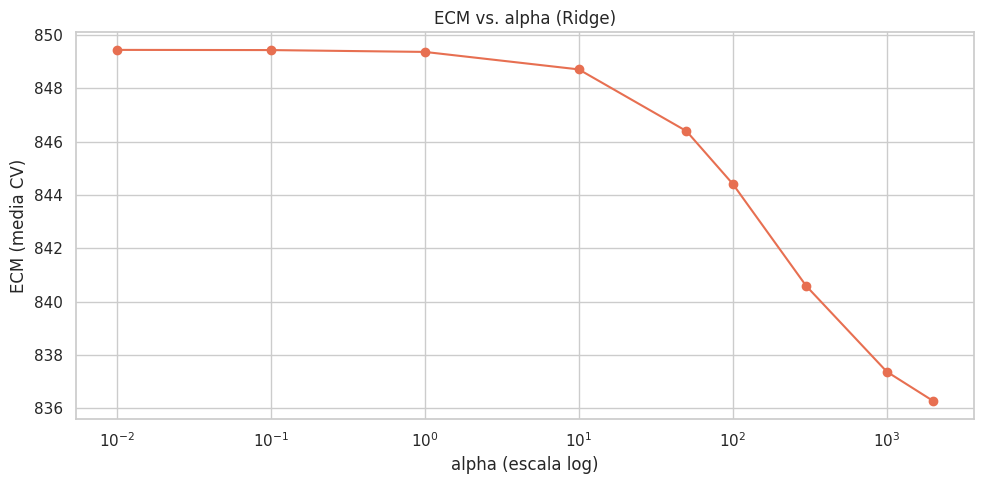

In [ ]:
# --- Grafico: ECM promedio de validacion cruzada en funcion de alpha ---
fig, ax = plt.subplots(figsize=(10, 5))
plot_reg = results_reg.sort_values('alpha')          # se ordena por alpha para que la linea tenga sentido
ax.plot(plot_reg['alpha'], plot_reg['ECM (media CV)'], marker='o', color='#e76f51')
ax.set_xscale('log')                                  # escala log porque alpha varia en varios ordenes de magnitud
ax.set_xlabel('alpha (escala log)')
ax.set_ylabel('ECM (media CV)')
ax.set_title('ECM vs. alpha (Ridge)')
plt.tight_layout()
plt.show()


**Lectura:** el ECM disminuye a medida que `alpha` crece, pero las mejoras son cada vez mas pequeñas (de 849.44 en alpha=0.01 a 836.28 en alpha=2000, con la mayor parte de esa mejora concentrada en alpha > 100). El mejor valor sigue siendo el extremo superior de esta malla (2000), asi que en sentido estricto el optimo podria estar todavia mas arriba; sin embargo, el ECM en el conjunto de prueba con este modelo (808.80) es practicamente identico al de un modelo trivial que predice siempre el promedio de entrenamiento (808.75, calculado en la celda siguiente) — la diferencia es menor al 0.01%. Esto tiene sentido incluso sin señal predictiva real: con `alpha` muy grande, Ridge encoge todos los coeficientes hacia cero y termina prediciendo, en la practica, el promedio general de `Financial Loss`, que es precisamente la prediccion que minimiza el ECM cuando no hay relacion real que capturar. Es decir, la mejora observada al aumentar `alpha` **no significa que el modelo este encontrando una relacion real**, sino que se esta acercando cada vez mas a la prediccion trivial del promedio — seguir ampliando la malla no cambiaria esta conclusion de forma relevante.

In [ ]:
# --- Evaluacion final sobre el conjunto de prueba, con el mejor modelo encontrado por el grid search ---
pred_reg = grid_reg.predict(X_test_reg)   # predicciones del mejor modelo sobre datos nunca vistos

print('ECM en conjunto de prueba:', mean_squared_error(y_test_reg, pred_reg))
print('Para referencia, ECM de predecir siempre el promedio de entrenamiento:',
      mean_squared_error(y_test_reg, np.full_like(y_test_reg, y_train_reg.mean())))


ECM en conjunto de prueba: 808.8011095737982
Para referencia, ECM de predecir siempre el promedio de entrenamiento: 808.7489262093229


**Interpretacion de los resultados de regresion:** el ECM del modelo ajustado es muy cercano al ECM de un modelo trivial que simplemente predice siempre el promedio de `Financial Loss` visto en entrenamiento. Esto confirma, desde el lado de regresion, la misma conclusion que en clasificacion: el modelo no logra explicar la variabilidad de `Financial Loss` mejor que una prediccion constante, consistente con la falta de correlacion observada en el EDA.

## 6. Conclusiones

1. **Metodologia:** tanto el problema de clasificacion (regresion logistica, 10-fold `StratifiedKFold`, metricas macro) como el de regresion (Ridge, 10-fold `KFold`, ECM) se implementaron con pipelines que evitan fuga de datos, con una busqueda de hiperparametros por malla cuyos resultados se compararon en tablas completas (no solo el mejor valor), y con un conjunto de prueba final independiente para la evaluacion honesta del mejor modelo.

2. **Resultado principal:** ni el modelo de clasificacion (F1 macro ≈ 0.17, equivalente al azar en 6 clases) ni el de regresion (ECM ≈ ECM de predecir el promedio) logran superar de forma significativa a un modelo trivial. Ampliar la malla de hiperparametros en ambos casos no cambio esta conclusion.

3. **Por que pasa esto:** el EDA mostro tres señales consistentes de que el dataset probablemente no conserva relaciones reales entre variables: (a) las variables numericas tienen su media casi exactamente en la mitad de su rango, tipico de una generacion uniforme; (b) todas las categorias de todas las variables categoricas estan casi uniformemente distribuidas, sin ninguna categoria dominante como se esperaria en datos reales; (c) la matriz de correlacion entre variables numericas no muestra ninguna relacion (todas ≈ 0).

4. **Limitacion de diseño del problema:** incluso si el dataset tuviera señal real, dos de las variables usadas como predictoras (`Defense Mechanism Used` e `Incident Resolution Time`) solo se conocen **despues** de resuelto el incidente. Para un caso de uso de prediccion en tiempo real (anticipar el tipo de un ataque en curso) estas variables no estarian disponibles y deberian excluirse del conjunto de predictores; aqui se mantuvieron porque el objetivo planteado es de caracterizacion retrospectiva, no de prediccion en tiempo real.

